cleaned version of 260618_pol_angle_groupings_150GHz.ipynb

# 6-21-2026


# Imports

In [1]:
# Basic imports
import numpy as np
import matplotlib.pyplot as plt
import os

# # For loading contexts
# from sotodlib import core

import pprint
import sys
import glob
import yaml
import time
import datetime as dt
import matplotlib as mpl
import scipy.signal as signal
import scipy.optimize as opt
from scipy import stats
# from latrt_testing import utils
# import latrt_testing.demodulation as demod
# from random import randrange
# import latrt_testing.fft_ops as fft_ops
# from so3g.hk import load_range

# from sotodlib.io.load_smurf import * 
# from sotodlib.tod_ops.fft_ops import rfft
# from sotodlib.tod_ops.detrend import detrend_tod
# from sotodlib.tod_ops import pca
# from sotodlib.io import load_smurf
# from sotodlib.io import hkdb

# import logging
# logger.setLevel(logging.DEBUG)

# import sotodlib
# from sotodlib.tod_ops.flags import get_glitch_flags, get_trending_flags
import importlib
from scipy.optimize import curve_fit

# from sotodlib.tod_ops import flags, detrend_tod, jumps, gapfill, pca, filters, apodize, fft_ops
# from sotodlib.core.flagman import has_any_cuts, has_all_cut
from pixell import utils
from scipy.signal import welch
from scipy.signal import hilbert

from matplotlib.markers import MarkerStyle
import scipy
import pickle

import re
import pandas as pd
import math
from scipy.optimize import least_squares
import astropy.units as u

from scipy.optimize import basinhopping

# Load data
1. passbands
2. hwp spectra

In [6]:
with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs1_150GHz_pW_260616.pkl', 'rb') as f:
    mv19_obs1 = pickle.load(f)

In [7]:
with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv19/band_attrs_obs4_150GHz_pW_260616.pkl', 'rb') as f:
    mv19_obs4 = pickle.load(f)

In [8]:
mv19_obs1['passband_results'][0].keys()

dict_keys(['det_name', 'det_band', 'det_channel', 'band', 'frequency_ghz', 'snr_local', 'local_ind', 'xi', 'eta', 'gamma', 'angles'])

In [9]:
# load in hwp phase shift information
mf1_ahwp = pd.read_csv('/global/homes/s/shreyasu/SAT FTS Analysis 202602/otherdata/MF1_AHWP_spectra.csv')

with open('/global/homes/s/shreyasu/SAT FTS Analysis 202602/FTS_data_mv18/phases_avg_run1_260527.pkl', 'rb') as f:
    data_mv18_hwp = pickle.load(f)

# Beamsplitter

In [10]:
# # constants
# n1, n2 = 1., 1.5
# d = (25.4 * u.um).to(u.m) # um (wavelengths should be in same units as d)
# f = np.arange(0.01, 250, 0.1) * u.GHz

# correction function
def reflectance_s_polarized_complex(n0, n1, d, theta_i, wavelength):
    # n1 may be complex
    theta_t1 = np.arcsin((n0 / np.real(n1)) * np.sin(theta_i))  # Approximation: use real part for angle
    # For accurate modeling, use complex n1 in cos(theta_t1):
    cos_theta_t1 = np.sqrt(1 - (n0*np.sin(theta_i)/n1)**2)

    # Fresnel coefficients for s-polarized (with complex n1)
    rs01 = (n0 * np.cos(theta_i) - n1 * cos_theta_t1) / (n0 * np.cos(theta_i) + n1 * cos_theta_t1)
    ts01 = (2 * n0 * np.cos(theta_i)) / (n0 * np.cos(theta_i) + n1 * cos_theta_t1)

    rs12 = (n1 * cos_theta_t1 - n0 * np.cos(theta_i)) / (n1 * cos_theta_t1 + n0 * np.cos(theta_i))

    # Complex phase thickness
    delta = (2 * np.pi * n1 * d * cos_theta_t1) / wavelength   # delta is complex
    
    # Interference with absorption
    numerator = rs01**2 + rs12**2 + 2 * rs01 * rs12 * np.cos(2 * np.real(delta)) * np.exp(-2 * np.imag(delta))
    denominator = 1 + (rs01 * rs12)**2 + 2 * rs01 * rs12 * np.cos(2 * np.real(delta)) * np.exp(-2 * np.imag(delta))
    Rs = np.abs(numerator/denominator)
    return Rs

In [11]:
c = 2.9979e8 
theta1 = 34.889 # degrees, aoi
# f_ghz = np.arange(1, 300, 0.1) * u.GHz
# f_hz = f_ghz.to(u.Hz)
# f_wavelengths = c / f_hz

In [12]:
# complex index for PP
n, eps = 1.5,2.25
k= 1j*np.emath.sqrt(n**2 -eps)
N = n + 1j*k
print(N)
print(k)

theta_i = np.radians(34.5)

# R_25um_pp = reflectance_s_polarized_complex(1, N, 25.4e-6, theta_i, f_wavelengths.value) # 25.4 um thickness# complex index for PP

(1.5+0j)
0j


# Preprocessing

In [13]:
# Preprocesssing to get the obs 1 and obs 4 data
xi1  = np.array([result['xi']  for result in mv19_obs1['passband_results']])
eta1 = np.array([result['eta'] for result in mv19_obs1['passband_results']])
gamma1 = np.array([result['gamma'] for result in mv19_obs1['passband_results']])

In [14]:
xi4  = np.array([result['xi']  for result in mv19_obs4['passband_results']])
eta4 = np.array([result['eta'] for result in mv19_obs4['passband_results']])
gamma4 = np.array([result['gamma'] for result in mv19_obs4['passband_results']])

In [12]:
# # Store SNR of these obs' bands
# snrs1 = np.array([result['snr_local'] for result in mv19_obs4['passband_results']])
# snrs4 = np.array([result['snr_local'] for result in mv19_obs4['passband_results']])

In [15]:
# Define the 12 colors
colors = ['#a6cee3',
'#1f78b4',
'#b2df8a',
'#33a02c',
'#fb9a99',
'#e31a1c',
'#fdbf6f',
'#ff7f00',
'#cab2d6',
'#6a3d9a',
'goldenrod', #'#ffff99',
'#b15928']

In [16]:
# # compare freqs for 1 and 4
# f1 = np.array(mv19_obs1['passband_results'][0]['frequency_ghz'])
# f4 = np.array(mv19_obs4['passband_results'][0]['frequency_ghz'])
# if np.array_equal(f1, f4):
#     print('True')

f = np.array(mv19_obs1['passband_results'][0]['frequency_ghz'])

In [17]:
# Grouping by polarization angle
bounds = [0, 0.5, 1, 1.75, 2.1, 2.4, 3, 3.8, 4.2, 4.5, 5.3, 5.8, 6.3]

In [18]:
# Sort the detectors into their polarization angle groups
n_groups = len(bounds) - 1
print(n_groups)

# automatically sort detector indices into n_groups phase groups
groups_obs1 = [[] for _ in range(n_groups)]
for i, gamma in enumerate(gamma1):
    for j in range(n_groups):
        if bounds[j] <= gamma < bounds[j + 1]:
            groups_obs1[j].append(i)
            break

groups_obs4 = [[] for _ in range(n_groups)]
for i, gamma in enumerate(gamma4):
    for j in range(n_groups):
        if bounds[j] <= gamma < bounds[j + 1]:
            groups_obs4[j].append(i)
            break

12


In [19]:
print('groups1:', groups_obs1)
print('groups4:', groups_obs4)

groups1: [[], [], [], [1, 3, 5, 7, 9, 11, 16, 19, 20, 24], [], [0, 4, 6, 8, 12, 17, 26], [13, 18, 22, 25], [], [2, 10, 14, 15, 21, 23, 27], [], [], []]
groups4: [[12, 15, 19, 28, 30], [], [], [], [], [], [], [2, 4, 5, 9, 13, 20, 24, 26], [], [0, 1, 6, 11, 17, 21, 22, 23, 25, 31], [3, 7, 8, 10, 14, 16, 18, 27, 29], []]


In [20]:
# Get the averaged pol angles per group

# also want to save the averaged gammas
gammas_avg = [[] for _ in range(n_groups)]

for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue

/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [21]:
print('gammas_avg:', gammas_avg, ' degrees')

gammas_avg: [7.663329, nan, nan, 112.519455, nan, 157.64127, 202.63916, 232.55017, 247.52036, 277.50308, 322.61475, nan]  degrees


In [22]:
# generating lists of the bands we care about
def average_grouped_bands(groups, passband_results, snr_threshold=5,
                          correction=None, norm_fac=1.0):
    """
    Average bands within each group, with optional correction and normalization.
    
    Parameters
    ----------
    groups : list of lists
        Group indices into passband_results.
    passband_results : list of dicts
        Each dict has 'band', 'frequency_ghz', 'snr_local'.
    snr_threshold : float
        Minimum SNR to include a band.
    correction : array-like or None
        Divide averaged band by this (e.g. R_25um_pp). None = no correction.
    norm_fac : float
        Multiply after correction. Default 1.0 (no normalization).
    
    Returns
    -------
    list : averaged (and optionally corrected/normalized) band per group.
    """
    n_groups = len(groups)
    bands = [None] * n_groups

    for g_idx, group in enumerate(groups):
        band_sum = 0
        band_counter = 0

        for j in (group if group else []):
            result = passband_results[j]
            snr = result['snr_local']
            if snr >= snr_threshold:
                band_sum = np.array(result['band']) + band_sum
                band_counter += 1

        if band_counter:
            band_avg = band_sum / band_counter
            if correction is not None:
                band_avg = band_avg / correction
            bands[g_idx] = band_avg * norm_fac
        else:
            bands[g_idx] = float('nan')

    return bands

In [23]:
SNR_THRESHOLD = 5

# Raw averages
bands_groups1 = average_grouped_bands(
    groups_obs1, mv19_obs1['passband_results'], snr_threshold=SNR_THRESHOLD
)

bands_groups4 = average_grouped_bands(
    groups_obs4, mv19_obs4['passband_results'], snr_threshold=SNR_THRESHOLD
)

In [24]:
# Beamsplitter corrected

# f: shared freuqency array in GHz
f_ghz = f * u.GHz
f_hz = f_ghz.to(u.Hz)
f_wavelengths = c / f_hz

R_25um_pp = reflectance_s_polarized_complex(1, N, 25.4e-6, theta_i, f_wavelengths.value) # 25.4 um thickness# complex index for PP


bands_groups1_bs = average_grouped_bands(
    groups_obs1, mv19_obs1['passband_results'], snr_threshold=SNR_THRESHOLD,
    correction=R_25um_pp
)
bands_groups4_bs = average_grouped_bands(
    groups_obs4, mv19_obs4['passband_results'], snr_threshold=SNR_THRESHOLD,
    correction=R_25um_pp
)

/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/tmp/ipykernel_347601/559713231.py:41: RuntimeWarning: divide by zero encountered in divide
  band_avg = band_avg / correction


In [34]:
# BS corrected + normalized (norm_fac depends on bands_groups4_bs, so compute it first)
lower_ind = 50
norm_fac = 1.0 / np.nanmax(bands_groups4_bs[9][lower_ind:])

bands_groups1_bs_norm = average_grouped_bands(
    groups_obs1, mv19_obs1['passband_results'], snr_threshold=SNR_THRESHOLD,
    correction=R_25um_pp, norm_fac=norm_fac
)
bands_groups4_bs_norm = average_grouped_bands(
    groups_obs4, mv19_obs4['passband_results'], snr_threshold=SNR_THRESHOLD,
    correction=R_25um_pp, norm_fac=norm_fac
)

/tmp/ipykernel_347601/559713231.py:41: RuntimeWarning: divide by zero encountered in divide
  band_avg = band_avg / correction


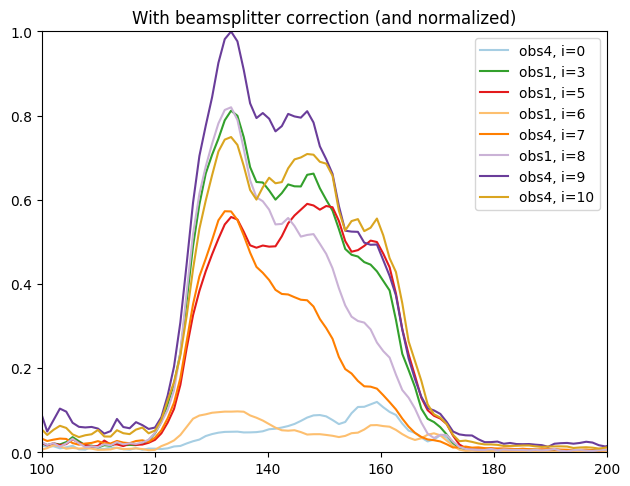

In [40]:
# plot each type of averaged band
plt.figure()

for i in range(n_groups):
    band1 = np.array(bands_groups1_bs_norm[i])
    band4 = np.array(bands_groups4_bs_norm[i])

    if np.ndim(band1) > 0:
        obs = 1
        mask1 = ~np.isnan(band1)
        plt.plot(f[mask1], band1[mask1], color=colors[i], label=f'obs{obs}, i={i}')

    if np.ndim(band4) > 0:
        obs = 4
        mask4 = ~np.isnan(band4)
        plt.plot(f[mask4], band4[mask4], color=colors[i], label=f'obs{obs}, i={i}')

# for i in range(n_groups):
#     band1 = np.array(bands_groups1[i])
#     band4 = np.array(bands_groups4[i])

#     if np.ndim(band1) > 0:
#         mask1 = ~np.isnan(band1)
#         plt.plot(f[mask1], np.array(band1[mask1]) / np.nanmax(bands_groups4[9]), color='grey', alpha=0.5)

#     if np.ndim(band4) > 0:
#         mask4 = ~np.isnan(band4)
#         plt.plot(f[mask4], np.array(band4[mask4]) / np.nanmax(bands_groups4[9]), color='grey', alpha=0.5)
plt.legend()

plt.xlim(100, 200)
plt.ylim(0, 1)
plt.tight_layout()
plt.title('With beamsplitter correction (and normalized)')
plt.show()

# Phase angle fit

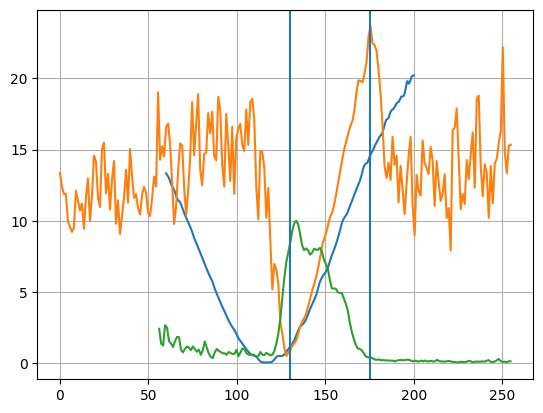

In [44]:
plt.figure()
plt.plot(mf1_ahwp['frequency (GHz)'], mf1_ahwp['phase shift (deg)'])
plt.plot(data_mv18_hwp['freq'], data_mv18_hwp['avg_phases150'] - 5.9)
# plot band overit
plt.plot(f[lower_ind:], bands_groups4_bs_norm[9][lower_ind:] * 10)
plt.axvline(130)
plt.axvline(175)
plt.grid('True')
plt.show()

In [70]:
# preprocess - get (x, y)

# frequency and phase for the HWP (with VNA)
f_hwp_vna = np.array(mf1_ahwp['frequency (GHz)'])
ps_hwp_vna = np.array(mf1_ahwp['phase shift (deg)'])

# with hwp modulated FTS
f_hwp_fts, ps_hwp_fts = np.array(data_mv18_hwp['freq']), np.array(data_mv18_hwp['avg_phases150']) - 5.9

In [71]:
# polynomial fitting

# quadratic fit over the full range for the HWP
coeffs_vna = np.polyfit(f_hwp_vna, ps_hwp_vna, 4)

# Generate the fit function
ps_hwp_vna_func = np.poly1d(coeffs_vna)
# ps_hwp_fit_vna = ps_hwp_vna_func(f_hwp_vna)

In [72]:
## FTS fit
bounds = [130, 175]
mask_fts_hwp = np.where((f_hwp_fts >= bounds[0])&(f_hwp_fts <= bounds[1]))

f_hwp_fts_masked, ps_hwp_fts_masked = f_hwp_fts[mask_fts_hwp], ps_hwp_fts[mask_fts_hwp]

coeffs_fts = np.polyfit(f_hwp_fts_masked, ps_hwp_fts_masked , 2)

# Generate the fitted data
ps_hwp_fts_func = np.poly1d(coeffs_fts)
# ps_hwp_fit_fts = ps_hwp_fts_func(f_hwp_fts_masked)

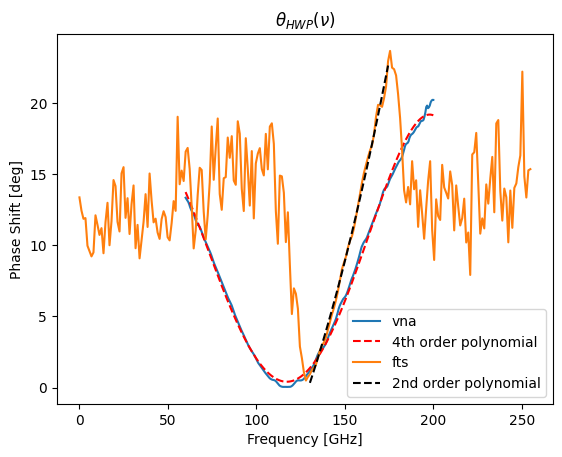

In [73]:
plt.figure()

## VNA
plt.plot(mf1_ahwp['frequency (GHz)'], mf1_ahwp['phase shift (deg)'], label='vna')
plt.plot(f_hwp_vna, ps_hwp_vna_func(f_hwp_vna), color='r', ls='--', label='4th order polynomial')

## FTS
plt.plot(f_hwp_fts, ps_hwp_fts, label='fts')
plt.plot(f_hwp_fts_masked, ps_hwp_fts_func(f_hwp_fts_masked), color='k', ls='--', label='2nd order polynomial')

plt.legend()
plt.xlabel('Frequency [GHz]')
plt.ylabel('Phase Shift [deg]')
plt.title(r'$\theta_{HWP}(\nu)$')
plt.show()

# Band fit

In [50]:
# fifht order fit
freq_fitting_bounds = [133, 160]
mask = (f >= freq_fitting_bounds[0]) & (f <= freq_fitting_bounds[1])

band_idx = 9
order = 5
coeffs_band = np.polyfit(f[mask], bands_groups4_bs_norm[band_idx][mask], order)
p_band_func = np.poly1d(coeffs_band)
# p_band_fit = p_band_func(f[mask])

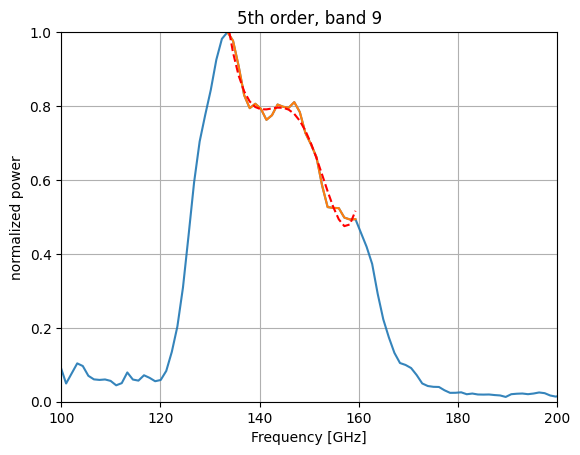

In [51]:
plt.figure()
plt.plot(f, bands_groups4_bs_norm[band_idx], alpha=0.9)
plt.plot(f[mask], bands_groups4_bs_norm[band_idx][mask])
plt.plot(f[mask], p_band_func(f[mask]), color='r', ls='--')
plt.xlim(100, 200)
plt.ylim(0, 1)
plt.title(f'{order}th order, band {band_idx}')
plt.xlabel('Frequency [GHz]')
plt.ylabel('normalized power')
plt.grid('True')
plt.show()

In [ ]:
# higher order R fit to use as a later guess

In [52]:
band_idx = 9
order_v2 = 15
coeffs_band_v2 = np.polyfit(f[mask], bands_groups4_bs_norm[band_idx][mask], order_v2)
p_band_func_v2 = np.poly1d(coeffs_band_v2)

/tmp/ipykernel_347601/288190119.py:3: RankWarning: Polyfit may be poorly conditioned
  coeffs_band_v2 = np.polyfit(f[mask], bands_groups4_bs_norm[band_idx][mask], order_v2)


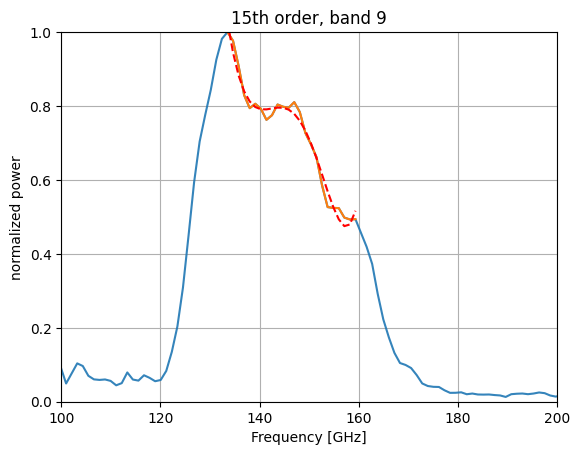

In [54]:
plt.figure()
plt.plot(f, bands_groups4_bs_norm[band_idx], alpha=0.9)
plt.plot(f[mask], bands_groups4_bs_norm[band_idx][mask])
plt.plot(f[mask], p_band_func(f[mask]), color='r', ls='--')
plt.xlim(100, 200)
plt.ylim(0, 1)
plt.title(f'{order_v2}th order, band {band_idx}')
plt.xlabel('Frequency [GHz]')
plt.ylabel('normalized power')
plt.grid('True')
plt.show()

# FIT 1

In [78]:
# ── config ──────────────────────────────────────────────────────────────────
POLY_DEG = order     # R(nu)
BAND_INDICES = [0, 3, 5, 6, 7, 8, 9, 10]
n_bands = 8
# which index comes from which group
BAND_SOURCES = {
    0: bands_groups4_bs_norm, 3: bands_groups1_bs_norm, 5: bands_groups1_bs_norm, 6: bands_groups1_bs_norm,
    7: bands_groups4_bs_norm, 8: bands_groups1_bs_norm, 9: bands_groups4_bs_norm, 10: bands_groups4_bs_norm,
}

In [63]:
# ── model functions ──────────────────────────────────────────────────────────
def R_nu(x, poly_coeffs):
    """Polynomial band response; degree = len(poly_coeffs) - 1."""
    return np.polyval(poly_coeffs, x)


def func3_vna(x, angle_pol, angle, const, alpha, poly_coeffs):
    # # Phase shift with vna
    angles_phase_shift = np.radians(ps_hwp_vna_func(x))

    angle_pol = np.radians(angle_pol)
    angle_rad = np.radians(angle)
    sine_arg = angle_pol + angles_phase_shift + angle
    R = R_nu(x, poly_coeffs)
    return alpha * R * np.sin(sine_arg) + const

def func3_fts(x, angle_pol, angle, const, alpha, poly_coeffs):
    # phase shift with fts
    angles_phase_shift = np.radians(ps_hwp_fts_func(x))

    angle_pol = np.radians(angle_pol)
    angle_rad = np.radians(angle)
    sine_arg = angle_pol + angles_phase_shift + angle
    R = R_nu(x, poly_coeffs)
    return alpha * R * np.sin(sine_arg) + const

In [64]:
# ── error function ───────────────────────────────────────────────────────────
def error_func3_vna(params, x_data_list, y_data_list, gammas):
    """
    params layout: [alpha_0, ..., alpha_n, angle_stat, poly_coeff_0, ..., poly_coeff_d]
    """
    n_bands = len(BAND_INDICES)
    alphas = params[:n_bands]
    angle_stat = params[n_bands]
    poly_coeffs = params[n_bands + 1:]          # length = POLY_DEG + 1

    freqs = x_data_list[0]
    residuals = [
        y_data_list[i] - np.abs(func3_vna(freqs, gammas[i], angle_stat, Cguess, alphas[i], poly_coeffs))
        for i in range(n_bands)
    ]
    return np.concatenate(residuals)

def error_func3_fts(params, x_data_list, y_data_list, gammas):
    """
    params layout: [alpha_0, ..., alpha_n, angle_stat, poly_coeff_0, ..., poly_coeff_d]
    """
    n_bands = len(BAND_INDICES)
    alphas = params[:n_bands]
    angle_stat = params[n_bands]
    poly_coeffs = params[n_bands + 1:]          # length = POLY_DEG + 1

    freqs = x_data_list[0]
    residuals = [
        y_data_list[i] - func3_fts(freqs, gammas[i], angle_stat, Cguess, alphas[i], poly_coeffs)
        for i in range(n_bands)
    ]
    return np.concatenate(residuals)

In [65]:
# ── prepare data ─────────────────────────────────────────────────────────────
freq_fitting_bounds = [135, 160]
mask = (f >= freq_fitting_bounds[0]) & (f <= freq_fitting_bounds[1])

x_data_list = [f[mask]] * len(BAND_INDICES)

y_data_list = [BAND_SOURCES[i][i][mask] for i in BAND_INDICES]

gammas = [gammas_avg[i] for i in BAND_INDICES]

In [66]:
# get better alpha_guesses by just looking at the in-band region
def masked_mean(band, mask):
    band = np.asarray(band)
    if band.ndim == 0:   # empty-group placeholder (scalar nan)
        return np.nan
    return np.nanmean(band[mask])

alpha_guesses_inband = [
    np.nanmean([masked_mean(bands_groups1_bs_norm[i], mask),
                masked_mean(bands_groups4_bs_norm[i], mask)])
    for i in range(n_groups)
]

/tmp/ipykernel_347601/3532082088.py:9: RuntimeWarning: Mean of empty slice
  np.nanmean([masked_mean(bands_groups1_bs_norm[i], mask),


In [74]:
# ── initial guess ────────────────────────────────────────────────────────────

# Just taking the mean of the bands for the alpha guesses
# alpha_guesses = [np.nanmean([np.nanmean(bands_groups1[i]), np.nanmean(bands_groups4[i])]) for i in range(n_groups)]
Cguess = 0
alpha_p0 = [alpha_guesses_inband[i] + 0.1 for i in BAND_INDICES] 
# alpha_p0 = np.array(alpha_p0) + 0.1 # add factor of 280 for 60th order poly; 250 for 25th order
angle_p0 = [230] # the fit value is always close to the guess no matter what the guess is
poly_p0  = list(coeffs_band[:POLY_DEG + 1])   # must supply POLY_DEG+1 coeffs

# alpha_const = [1.] * n_bands
p0_v3 = alpha_p0 + angle_p0 + poly_p0
# alpha_const = 1
# p0_v3 = alpha_const + angle_p0 + poly_p0

# # when using vna hwp
# result_v3 = least_squares(error_func3_vna, p0_v3, args=(x_data_list, y_data_list, gammas))

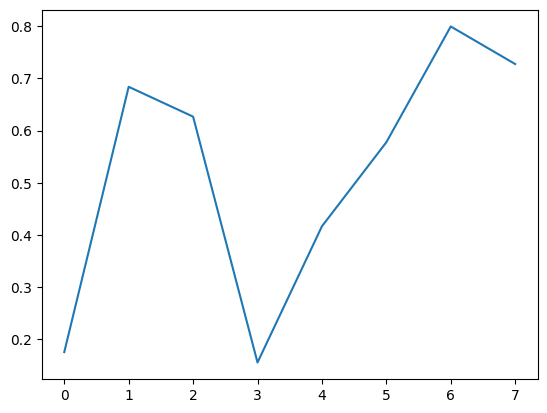

In [75]:
plt.figure()
plt.plot(alpha_p0)
plt.show()

In [76]:
lb

NameError: name 'lb' is not defined

In [134]:
# print(len(alpha_p0))
# print(len(angle_p0))
# print(len(poly_p0))

In [135]:
# ── unpack results ────────────────────────────────────────────────────────────
n_bands = len(BAND_INDICES)
fitted_alphas_vna  = dict(zip(BAND_INDICES, result_v3.x[:n_bands]))
fitted_alphas_arr_vna = result_v3.x[:n_bands]
angle_stat_fit_vna = result_v3.x[n_bands]
poly_fit_vna       = result_v3.x[n_bands + 1:]

In [79]:
# Redoing fit for positive alphas
# Redo the fit above but restrict the 

# n_bands = len(BAND_INDICES)
# n_poly  = POLY_DEG + 1

# # Lower bounds: alphas > 0, angle unconstrained, poly unconstrained
# lb = [0.0] * n_bands + [-np.inf] + [-np.inf] * n_bands

# # Upper bounds: everything unconstrained
# ub = [np.inf] * n_bands + [np.inf] + [np.inf] * n_bands

lb = [-np.inf] * len(p0_v3) #[-np.inf] * len(p0_v3)
# lb[:n_bands] = [0.0] * n_bands
lb[:n_bands] = [0.1] * n_bands

# print(lb)
ub = [ np.inf] * len(p0_v3)
ub[:n_bands] = [10] * n_bands

# result_v3_posalpha = least_squares(
#     error_func3_vna,
#     p0_v3,
#     args=(x_data_list, y_data_list, gammas),
#     bounds=(lb, ub)
# )

alpha_p0 = [alpha_guesses_inband[i] + 0.1 for i in BAND_INDICES] 
p0_v3 = alpha_p0 + angle_p0 + poly_p0


# result_v3_posalpha = basinhopping(
#     error_func3_vna,
#     p0_v3,
#     args=(x_data_list, y_data_list, gammas),
#     bounds=(lb, ub)
# )

In [80]:
def scalar_error_v3(params, x_data_list, y_data_list, gammas):
    residuals = error_func3_vna(params, x_data_list, y_data_list, gammas)
    return np.sum(residuals**2)

result_v3_posalpha = basinhopping(
    scalar_error_v3,
    p0_v3,
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "args": (x_data_list, y_data_list, gammas),
        "bounds": list(zip(lb, ub))  # L-BFGS-B expects [(lb0,ub0), (lb1,ub1), ...]
    }
)

In [256]:
ub

[1.25,
 1.25,
 1.25,
 1.25,
 1.25,
 1.25,
 1.25,
 1.25,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf,
 inf]

In [81]:
# ── unpack results ────────────────────────────────────────────────────────────
# n_bands = len(BAND_INDICES)
fitted_alphas_posalpha  = dict(zip(BAND_INDICES, result_v3_posalpha.x[:n_bands]))
fitted_alphas_arr_posalpha = result_v3_posalpha.x[:n_bands]
angle_stat_fit_posalpha = result_v3_posalpha.x[n_bands]
poly_fit_posalpha       = result_v3_posalpha.x[n_bands + 1:]

In [232]:
fitted_alphas_arr_posalpha

array([ 0.1       ,  0.1       , 10.        ,  0.16607568,  0.73005224,
        1.12360132,  2.08342222, 10.        ])

In [203]:
gammas

[7.663329,
 112.519455,
 157.64127,
 202.63916,
 232.55017,
 247.52036,
 277.50308,
 322.61475]

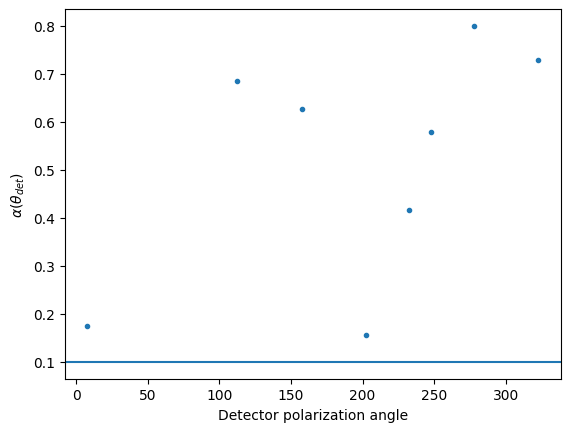

In [82]:
plt.figure()
plt.plot(gammas, fitted_alphas_arr_posalpha, '.')
plt.axhline(0.1)
# plt.semilogy()
plt.ylabel(r'$\alpha (\theta_{det})$')
plt.xlabel('Detector polarization angle')
plt.show()

In [ ]:
# # Repeat for when the fts hwp spectrum is used

# # when using fts hwp
# result_v3_fts = least_squares(error_func3_fts, p0_v3, args=(x_data_list, y_data_list, gammas))

# fitted_alphas_fts  = dict(zip(BAND_INDICES, result_v3_fts.x[:n_bands]))
# fitted_alphas_arr_fts = result_v3_fts.x[:n_bands]
# angle_stat_fit_fts = result_v3_fts.x[n_bands]
# poly_fit_fts       = result_v3_fts.x[n_bands + 1:]


In [83]:
def scalar_error_v3_fts(params, x_data_list, y_data_list, gammas):
    residuals = error_func3_fts(params, x_data_list, y_data_list, gammas)
    return np.sum(residuals**2)

result_v3_posalpha_fts = basinhopping(
    scalar_error_v3_fts,
    p0_v3,
    minimizer_kwargs={
        "method": "L-BFGS-B",
        "args": (x_data_list, y_data_list, gammas),
        "bounds": list(zip(lb, ub))  # L-BFGS-B expects [(lb0,ub0), (lb1,ub1), ...]
    }
)

In [84]:
# ── unpack results ────────────────────────────────────────────────────────────
# n_bands = len(BAND_INDICES)
fitted_alphas_posalpha_fts  = dict(zip(BAND_INDICES, result_v3_posalpha_fts.x[:n_bands]))
fitted_alphas_arr_posalpha_fts = result_v3_posalpha_fts.x[:n_bands]
angle_stat_fit_posalpha_fts = result_v3_posalpha_fts.x[n_bands]
poly_fit_posalpha_fts       = result_v3_posalpha_fts.x[n_bands + 1:]

In [86]:
# compare fts vs vna hwp fit results
print('vna fits\n')
print('fitted alphas_vna:', fitted_alphas_posalpha)
print('poly_fit_vna:', poly_fit_posalpha)
print('angle stat fit_vna:', angle_stat_fit_posalpha)

print('\nfts fits')
print('fitted alphas_vna:', fitted_alphas_posalpha_fts)
print('poly_fit_vna:', poly_fit_posalpha_fts)
print('angle stat fit_vna:', angle_stat_fit_posalpha_fts)

vna fits

fitted alphas_vna: {0: 0.1758172863712702, 3: 0.6840392956978328, 5: 0.626881627693493, 6: 0.15588603234654452, 7: 0.4167548448143137, 8: 0.5777926481468084, 9: 0.7996123838588591, 10: 0.7276602174675293}
poly_fit_vna: [ 3.92913022e-07 -2.71377708e-04  7.45819161e-02 -1.01893597e+01
  6.91534948e+02 -1.86347728e+04]
angle stat fit_vna: 230.0

fts fits
fitted alphas_vna: {0: 0.1758172863712702, 3: 0.6840392956978328, 5: 0.626881627693493, 6: 0.15588603234654452, 7: 0.4167548448143137, 8: 0.5777926481468084, 9: 0.7996123838588591, 10: 0.7276602174675293}
poly_fit_vna: [ 3.92913022e-07 -2.71377708e-04  7.45819161e-02 -1.01893597e+01
  6.91534948e+02 -1.86347728e+04]
angle stat fit_vna: 230.0


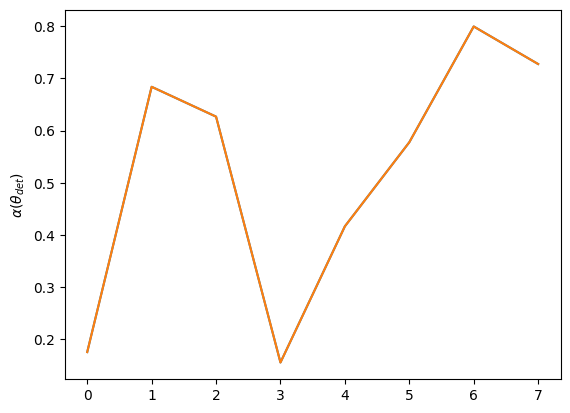

In [88]:
# visualize if the alphas are different
plt.figure()
plt.plot(fitted_alphas_arr_posalpha, label='fitting alphas when using vna hwp')
plt.plot(fitted_alphas_arr_posalpha_fts, label='fitting alphas when using fts hwp')
# plt.xlabel('')
plt.ylabel(r'$\alpha (\theta_{det})$')
plt.show()

In [89]:
# R fits using fts vs vna hwp spectrum
fitfuncvna = np.poly1d(poly_fit_posalpha)
fitfuncfts = np.poly1d(poly_fit_posalpha_fts)

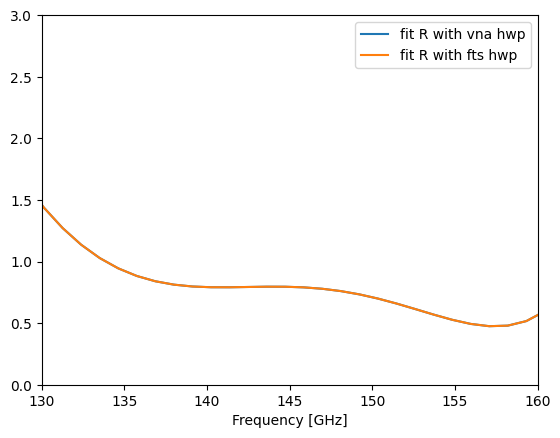

In [90]:
# compare polynomials for R
plt.figure()
# plt.plot(f, guessfunc(f), label='guess from band 9')
# plt.plot(f, fitfunc(f), label='fit only R')
plt.plot(f, fitfuncvna(f), label='fit R with vna hwp')
plt.plot(f, fitfuncfts(f), label='fit R with fts hwp')

plt.legend()
plt.xlim(130, 160)
plt.ylim(0, 3)
plt.xlabel('Frequency [GHz]')
plt.show()

# PLOT 1

/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/s/shreyasu/lart_testing_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


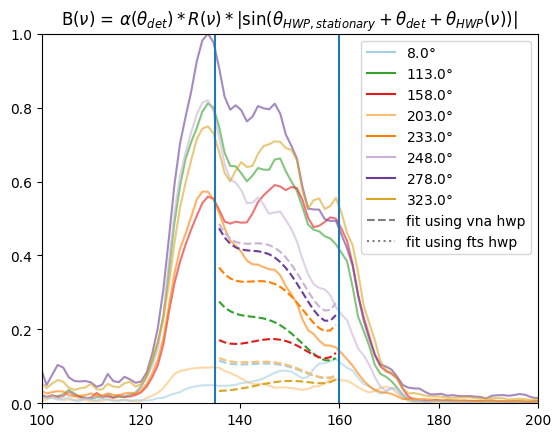

In [92]:
# ALPHAS RESTRICTED TO BE POSITIVE

# REDONE for the beamsplitter corrected case

# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure()
# fig, ax = plt.subplots(1, 2)

for i in range(n_groups):
    band = np.array(bands_groups1_bs_norm[i])
    freq = mv19_obs1['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)

for i in range(n_groups):
    band = np.array(bands_groups4_bs_norm[i])
    freq = mv19_obs4['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)
    
# fit when using vna hwp
for i, alpha_fit in fitted_alphas_posalpha.items():
    y_fit = func3_vna(f[mask], gammas_avg[i], angle_stat_fit_posalpha, Cguess, alpha_fit, poly_fit_posalpha)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='--')

# # fit when using fts hwp
# for i, alpha_fit in fitted_alphas_fts.items():
#     y_fit = func3_fts(f[mask], gammas_avg[i], angle_stat_fit_fts, Cguess, alpha_fit, poly_fit_fts)
#     plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls=':')

# Label the pol angles
for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue
    plt.plot([], [], color=color, label=rf'{np.round(gamma_avg)}$\degree$')

plt.plot([],[],color='grey', ls='--', label='fit using vna hwp')
plt.plot([],[],color='grey', ls=':', label='fit using fts hwp')

plt.legend(bbox_to_anchor=(1,1))
plt.xlim(100, 200)
plt.ylim(0, 1)
# plt.axvspan(130, 160, alpha=0.5)
plt.axvline(135)
plt.axvline(160)
# ax[0].axhline(0.06, ls='--')
# ax[1].axhline(0.06, ls='--')
equationString = r'B($\nu$) = $\alpha (\theta_{det}) * R(\nu) * |$sin($\theta_{HWP, stationary} + \theta_{det} + \theta_{HWP}(\nu)$)|'

plt.title(equationString)
plt.show()

In [263]:
# gammas_avg
# gammas

[7.663329,
 112.519455,
 157.64127,
 202.63916,
 232.55017,
 247.52036,
 277.50308,
 322.61475]

In [209]:
residuals_posalpha = {}
# residuals_fts = {}
freq = mv19_obs1['passband_results'][0]['frequency_ghz']

for i, alpha_fit in fitted_alphas_posalpha.items():
    y_fit = func3_vna(f[mask], gammas_avg[i], angle_stat_fit_posalpha, Cguess, alpha_fit, poly_fit_posalpha)
    
    # y_fit = np.abs(func3_vna(f[mask], gammas_avg[i], angle_stat_fit_posalpha, Cguess, alpha_fit, poly_fit_posalpha))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals_vna[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals_vna[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals_posalpha[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

# for i, alpha_fit in fitted_alphas_fts.items():
#     y_fit = np.abs(func3_fts(f[mask], gammas_avg[i], angle_stat_fit_fts, Cguess, alpha_fit, poly_fit_fts))
#     y_fit_interp = np.interp(freq, f[mask], y_fit)

#     residuals_fts[i] = {}
#     for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
#         band = np.array(band_norm)
#         if np.ndim(band) == 0:
#             residuals_fts[i][obs] = None
#             continue
#         mask_ = ~np.isnan(band)
#         residuals_fts[i][obs] = {
#             'freq': freq[mask_],
#             'resid': band[mask_] - y_fit_interp[mask_],
#         }

KeyError: 0

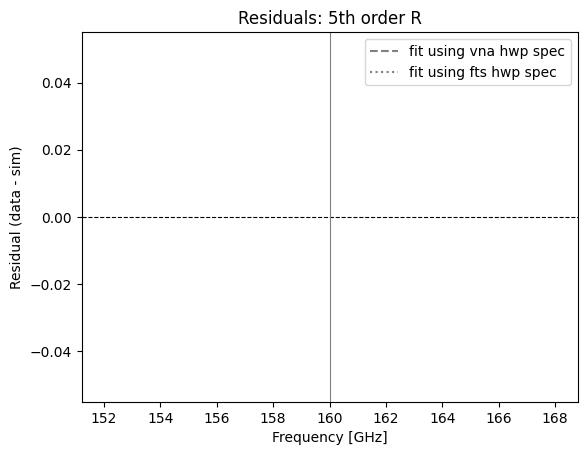

In [208]:
plt.figure()

# vna hwp residuals
for i, obs_residuals in residuals_posalpha.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= 130) & (val['freq'] <= 160)
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls='--')

# # residuals when using the fts hwp spectrum
# for i, obs_residuals in residuals_fts.items():
#     for obs, val in obs_residuals.items():
#         if val is not None:
#             freq_mask = (val['freq'] >= 130) & (val['freq'] <= 160)
#             plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls=':')

# dashed is with vna hwp spectrum
plt.plot([],[], color='grey', ls='--', label='fit using vna hwp spec')
plt.plot([],[], color='grey', ls=':', label='fit using fts hwp spec')

plt.axhline(0, color='k', lw=0.8, ls='--')
# plt.axvline(130, color='gray', lw=0.8)
plt.axvline(160, color='gray', lw=0.8)
# plt.xlim(129, 160)
plt.legend()
plt.xlabel('Frequency [GHz]')
plt.ylabel('Residual (data - sim)')
plt.title(f'Residuals: {order}th order R')
plt.show()

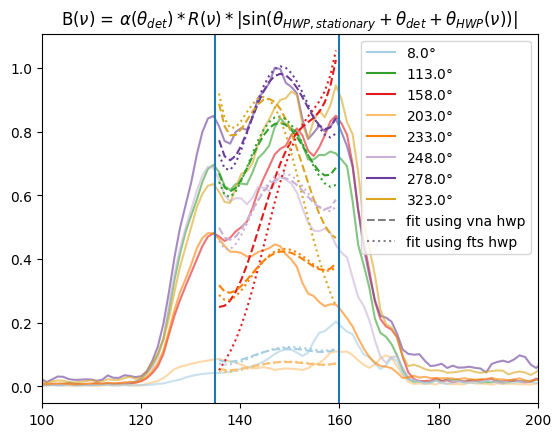

In [141]:
# REDONE for the beamsplitter corrected case

# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure()
# fig, ax = plt.subplots(1, 2)

for i in range(n_groups):
    band = np.array(bands_groups1_bs_norm[i])
    freq = mv19_obs1['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)

for i in range(n_groups):
    band = np.array(bands_groups4_bs_norm[i])
    freq = mv19_obs4['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)
    
# fit when using vna hwp
for i, alpha_fit in fitted_alphas_vna.items():
    y_fit = func3_vna(f[mask], gammas_avg[i], angle_stat_fit_vna, Cguess, alpha_fit, poly_fit_vna)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='--')

# fit when using fts hwp
for i, alpha_fit in fitted_alphas_fts.items():
    y_fit = func3_fts(f[mask], gammas_avg[i], angle_stat_fit_fts, Cguess, alpha_fit, poly_fit_fts)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls=':')

# Label the pol angles
for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue
    plt.plot([], [], color=color, label=rf'{np.round(gamma_avg)}$\degree$')

plt.plot([],[],color='grey', ls='--', label='fit using vna hwp')
plt.plot([],[],color='grey', ls=':', label='fit using fts hwp')

plt.legend()
plt.xlim(100, 200)

# plt.axvspan(130, 160, alpha=0.5)
plt.axvline(135)
plt.axvline(160)
# ax[0].axhline(0.06, ls='--')
# ax[1].axhline(0.06, ls='--')
equationString = r'B($\nu$) = $\alpha (\theta_{det}) * R(\nu) * |$sin($\theta_{HWP, stationary} + \theta_{det} + \theta_{HWP}(\nu)$)|'

plt.title(equationString)
plt.show()

In [143]:
residuals_vna = {}
residuals_fts = {}
freq = mv19_obs1['passband_results'][0]['frequency_ghz']

for i, alpha_fit in fitted_alphas_vna.items():
    y_fit = np.abs(func3_vna(f[mask], gammas_avg[i], angle_stat_fit_vna, Cguess, alpha_fit, poly_fit_vna))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals_vna[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals_vna[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals_vna[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

for i, alpha_fit in fitted_alphas_fts.items():
    y_fit = np.abs(func3_fts(f[mask], gammas_avg[i], angle_stat_fit_fts, Cguess, alpha_fit, poly_fit_fts))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals_fts[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals_fts[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals_fts[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

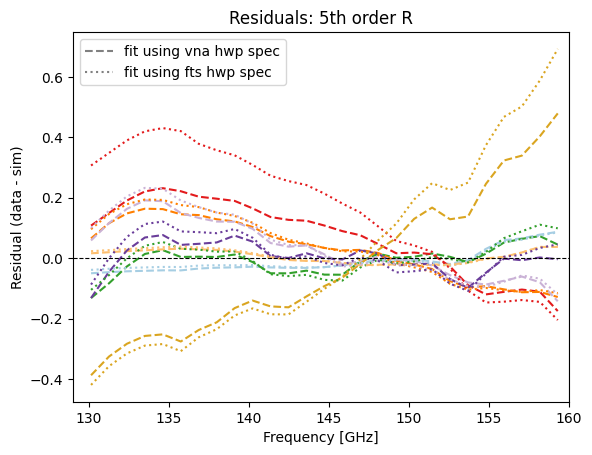

In [144]:
plt.figure()

# vna hwp residuals
for i, obs_residuals in residuals_vna.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= 130) & (val['freq'] <= 160)
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls='--')

# residuals when using the fts hwp spectrum
for i, obs_residuals in residuals_fts.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= 130) & (val['freq'] <= 160)
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls=':')

# dashed is with vna hwp spectrum
plt.plot([],[], color='grey', ls='--', label='fit using vna hwp spec')
plt.plot([],[], color='grey', ls=':', label='fit using fts hwp spec')

plt.axhline(0, color='k', lw=0.8, ls='--')
# plt.axvline(130, color='gray', lw=0.8)
plt.axvline(160, color='gray', lw=0.8)
plt.xlim(129, 160)
plt.legend()
plt.xlabel('Frequency [GHz]')
plt.ylabel('Residual (data - sim)')
plt.title(f'Residuals: {order}th order R')
plt.show()

# FIT 2
Fit to just R(nu)

In [111]:
# ── error function ───────────────────────────────────────────────────────────
def error_func3_fitR(params, x_data_list, y_data_list, gammas):
    """
    params layout: [alpha_0, ..., alpha_n, angle, poly_coeff_0, ..., poly_coeff_d]
    """
    n_bands = len(BAND_INDICES)
    # alphas = params[:n_bands]
    # angle = params[n_bands]
    poly_coeffs = params          # length = POLY_DEG + 1

    freqs = x_data_list[0]
    residuals = [
        y_data_list[i] - func3_vna(freqs, gammas[i], angle_stat_fit_vna, Cguess, fitted_alphas_arr_vna[i], poly_coeffs)
        for i in range(n_bands)
    ]
    return np.concatenate(residuals)

In [112]:
# guess params for R(nu)
poly_p0  = list(coeffs_band[:POLY_DEG + 1])   # must supply POLY_DEG+1 coeffs

p0_v3 = poly_p0

result_v3_fitR = least_squares(error_func3_fitR, p0_v3, args=(x_data_list, y_data_list, gammas))
poly_fit_fitR = result_v3_fitR.x

In [113]:
# Comparison of guess vs fit polyfit
print('Guess:', poly_p0)
print('Fit:', poly_fit_fitR)

Guess: [4.839231571418262e-14, -4.41573526168691e-11, 1.5197172212960973e-08, -2.010741324052147e-06, -9.010728544896607e-05, 0.049531644001377, -1.021254070654205, -1119.4064810360167, 171699.57292161693, -10636204.65974884, 251439676.03522822]
Fit: [ 4.73313719e-14 -4.34843810e-11  1.50988874e-08 -2.03554011e-06
 -8.04993050e-05  4.85566051e-02 -1.02155666e+00 -1.11740157e+03
  1.72519991e+05 -1.07468153e+07  2.55366575e+08]


In [114]:
# plot the different models to compare how they change with different fit setups
guessfunc = np.poly1d(poly_p0)
fitfunc = np.poly1d(poly_fit_fitR)

# from earlier
fitfuncvna = np.poly1d(poly_fit_vna)
fitfuncfts = np.poly1d(poly_fit_fts)

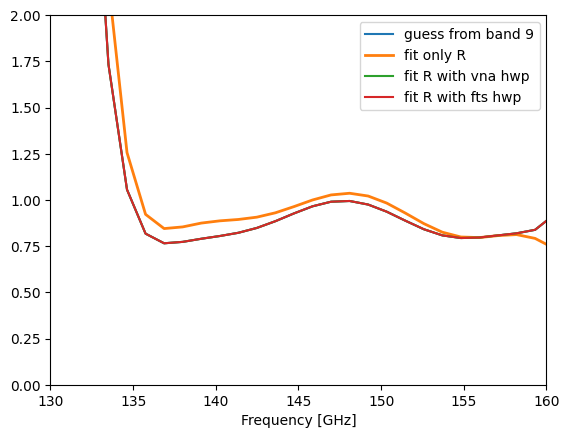

In [115]:
plt.figure()
plt.plot(f, guessfunc(f), label='guess from band 9')
plt.plot(f, fitfunc(f), label='fit only R', lw=2)
plt.plot(f, fitfuncvna(f), label='fit R with vna hwp')
plt.plot(f, fitfuncfts(f), label='fit R with fts hwp')

plt.legend()
plt.xlim(130, 160)
plt.ylim(0, 2)
plt.xlabel('Frequency [GHz]')
plt.show()

# PLOT 2
Fit R (all others constant)

In [116]:
angle_stat_fit_vna

230.0

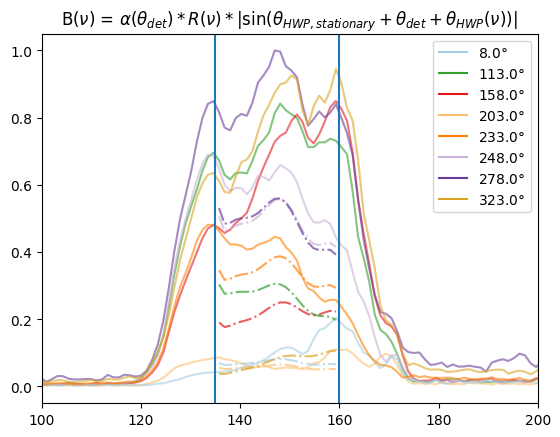

In [117]:
# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure()
# fig, ax = plt.subplots(1, 2)

for i in range(n_groups):
    band = np.array(bands_groups1_bs_norm[i])
    freq = mv19_obs1['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)

for i in range(n_groups):
    band = np.array(bands_groups4_bs_norm[i])
    freq = mv19_obs4['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)
    
# fit when using vna hwp and fitted to R with other stuff constant
for i, alpha_fit in fitted_alphas_vna.items():
    y_fit = func3_vna(f[mask], gammas_avg[i], angle_stat_fit_vna, Cguess, alpha_fit, poly_fit_fitR)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='-.', alpha=0.7)

    # y_fit = func3_vna(f[mask], gammas_avg[i], 265, Cguess, alpha_fit, poly_fit_fitR)
    # plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='-.')

# # fit when using fts hwp
# for i, alpha_fit in fitted_alphas_fts.items():
#     y_fit = func3_fts(f[mask], gammas_avg[i], angle_stat_fit_fts, Cguess, alpha_fit, poly_fit_fts)
#     plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls=':')

# Label the pol angles
for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue
    plt.plot([], [], color=color, label=rf'{np.round(gamma_avg)}$\degree$')

plt.legend()
# 
plt.xlim(100, 200)

# plt.axvspan(130, 160, alpha=0.5)
plt.axvline(135)
plt.axvline(160)
# ax[0].axhline(0.06, ls='--')
# ax[1].axhline(0.06, ls='--')
equationString = r'B($\nu$) = $\alpha (\theta_{det}) * R(\nu) * |$sin($\theta_{HWP, stationary} + \theta_{det} + \theta_{HWP}(\nu)$)|'

plt.title(equationString)
plt.show()

In [118]:
residuals_vna_fitR = {}
# freq = mv19_obs1['passband_results'][0]['frequency_ghz']

for i, alpha_fit in fitted_alphas_vna.items():
    y_fit = np.abs(func3_vna(f[mask], gammas_avg[i], angle_stat_fit_vna, Cguess, alpha_fit, poly_fit_fitR))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals_vna_fitR[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals_vna_fitR[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals_vna_fitR[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

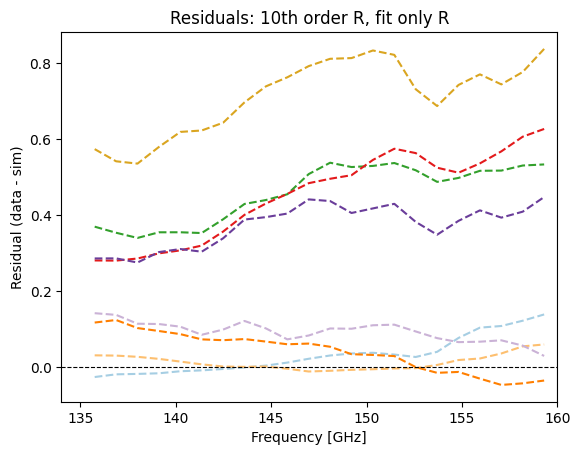

In [119]:
plt.figure()

# vna hwp residuals and fitting to only R
for i, obs_residuals in residuals_vna_fitR.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= 135) & (val['freq'] <= 160)
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls='--')

plt.axhline(0, color='k', lw=0.8, ls='--')
# plt.axvline(130, color='gray', lw=0.8)
plt.axvline(160, color='gray', lw=0.8)
plt.xlim(134, 160)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Residual (data - sim)')
plt.title(f'Residuals: {order}th order R, fit only R')
plt.show()

# FIT 3
Fit to the HWP spectrum
- avg the quadratic fit params for the vna and fts hwp spectra
- use the fit R
- average the alphas from the fit params 
- average the stationary hwp angle

In [120]:
def hwp_phase_nu(x, poly_coeffs):
    """HWP phase-shift polynomial; degree = len(poly_coeffs) - 1 (2nd order)."""
    return np.polyval(poly_coeffs, x)


def func3_fit_hwp_ps(x, angle_pol, angle, const, alpha, R_poly_coeffs, hwp_poly_coeffs):

    # Phase shift is now the thing being fit — quadratic, via hwp_phase_nu
    angles_phase_shift = np.radians(hwp_phase_nu(x, hwp_poly_coeffs))
    angle_pol = np.radians(angle_pol)
    angle_rad = np.radians(angle)
    sine_arg = angle_pol + angles_phase_shift + angle_rad
    R = R_nu(x, R_poly_coeffs)
    return alpha * R * np.sin(sine_arg) + const


def error_func3_fit_hwp_ps(params, x_data_list, y_data_list, gammas, alphas, angle_stat, R_poly_coeffs):
    """
    params layout: [hwp_poly_coeff_0, hwp_poly_coeff_1, hwp_poly_coeff_2]  (2nd order)
    alphas, angle_stat, and R_poly_coeffs (band response, 6th order) are fixed givens.
    """
    hwp_poly_coeffs = params
    n_bands = len(BAND_INDICES)

    freqs = x_data_list[0]
    residuals = [
        y_data_list[i] - func3_fit_hwp_ps(freqs, gammas[i], angle_stat, Cguess, alphas[i], R_poly_coeffs, hwp_poly_coeffs)
        for i in range(n_bands)
    ]
    return np.concatenate(residuals)

In [121]:
# guesses
# ── initial guess: 2nd order polynomial for the HWP phase shift ─────────────
# average the params for the fts and vna
fmask_vna = np.where((f_hwp_vna >= bounds[0])&(f_hwp_vna <= bounds[1]))
coeffs_vna_quad = np.polyfit(f_hwp_vna[fmask_vna], ps_hwp_vna[fmask_vna], 2) # should only be data in the bounds

In [122]:
vna_quad_func = np.poly1d(coeffs_vna_quad)

In [123]:
# ── fixed givens: average of the VNA-based and FTS-based band fits ──────────
x_avg = (result_v3.x + result_v3_fts.x) / 2
fitted_alphas_arr_avg = x_avg[:n_bands]
angle_stat_fit_avg    = x_avg[n_bands]
# poly_fit_avg          = x_avg[n_bands + 1:], use poly_fit_fitR

# ── initial guess: average of VNA and FTS quadratic HWP phase-shift fits ────
# mask_vna = np.where((f_hwp_vna >= bounds[0]) & (f_hwp_vna <= bounds[1]))
# coeffs_vna_quad = np.polyfit(f_hwp_vna[mask_vna], ps_hwp_vna[mask_vna], 2)

# mask_fts = np.where((f_hwp_fts >= bounds[0]) & (f_hwp_fts <= bounds[1]))
# coeffs_fts_quad = np.polyfit(f_hwp_fts[mask_fts], ps_hwp_fts[mask_fts], 2)

p0_v3_hwp_ps_avg = list((coeffs_vna_quad + coeffs_fts) / 2)

result_v3_fit_hwp_ps = least_squares(
    error_func3_fit_hwp_ps, p0_v3_hwp_ps_avg,
    args=(x_data_list, y_data_list, gammas, fitted_alphas_arr_avg, angle_stat_fit_avg, poly_fit_fitR)
)

hwp_poly_fit = result_v3_fit_hwp_ps.x
hwp_poly_fit_func = np.poly1d(hwp_poly_fit)

In [124]:
fitted_alphas_avg  = dict(zip(BAND_INDICES, fitted_alphas_arr_avg))

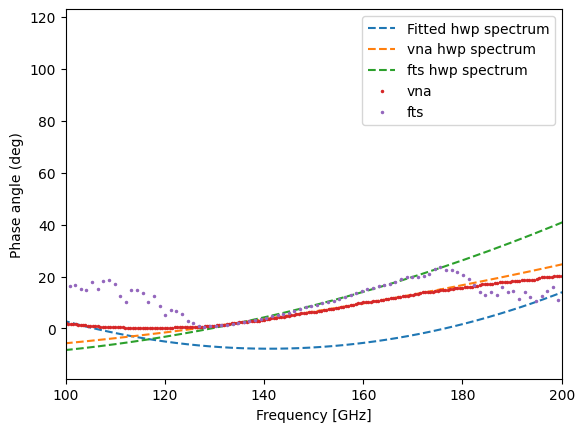

In [125]:
# See how different hwp spectra compare
plt.figure()
plt.plot(f, hwp_poly_fit_func(f), ls='--', label='Fitted hwp spectrum')
plt.plot(f, vna_quad_func(f), ls='--', label='vna hwp spectrum')
plt.plot(f, ps_hwp_fts_func(f), ls='--', label='fts hwp spectrum')


## VNA
plt.plot(mf1_ahwp['frequency (GHz)'], mf1_ahwp['phase shift (deg)'], '.', markersize=3, label='vna')

## FTS
plt.plot(f_hwp_fts, ps_hwp_fts, '.', markersize=3,label='fts')


plt.legend()
# plt.xlim(100, 200)
# plt.ylim(-200, 100)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Phase angle (deg)')
plt.show()

# PLOT 3

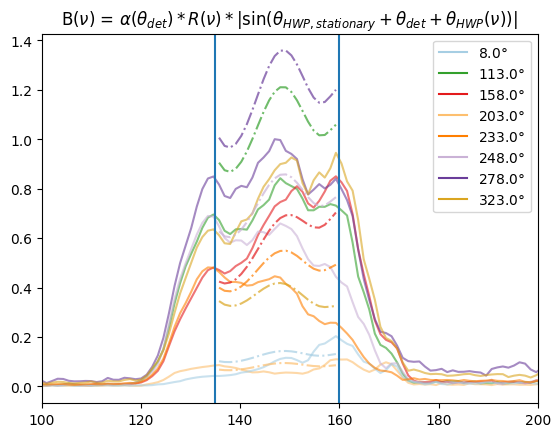

In [90]:
# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure()
# fig, ax = plt.subplots(1, 2)

for i in range(n_groups):
    band = np.array(bands_groups1_bs_norm[i])
    freq = mv19_obs1['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)

for i in range(n_groups):
    band = np.array(bands_groups4_bs_norm[i])
    freq = mv19_obs4['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)
    
for i, alpha_fit in fitted_alphas_avg.items():
    y_fit = func3_fit_hwp_ps(f[mask], gammas_avg[i], angle_stat_fit_avg, Cguess, alpha_fit, poly_fit_fitR, hwp_poly_fit)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='-.', alpha=0.7)

# Label the pol angles
for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue
    plt.plot([], [], color=color, label=rf'{np.round(gamma_avg)}$\degree$')

plt.legend()
# 
plt.xlim(100, 200)

# plt.axvspan(130, 160, alpha=0.5)
plt.axvline(135)
plt.axvline(160)
# ax[0].axhline(0.06, ls='--')
# ax[1].axhline(0.06, ls='--')
equationString = r'B($\nu$) = $\alpha (\theta_{det}) * R(\nu) * |$sin($\theta_{HWP, stationary} + \theta_{det} + \theta_{HWP}(\nu)$)|'

plt.title(equationString)
plt.show()

In [91]:
residuals_fitting_hwp_ps = {}
# freq = mv19_obs1['passband_results'][0]['frequency_ghz']

for i, alpha_fit in fitted_alphas_avg.items():
    y_fit = np.abs(func3_fit_hwp_ps(f[mask], gammas_avg[i], angle_stat_fit_avg, Cguess, alpha_fit, poly_fit_fitR, hwp_poly_fit))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals_fitting_hwp_ps[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals_fitting_hwp_ps[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals_fitting_hwp_ps[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

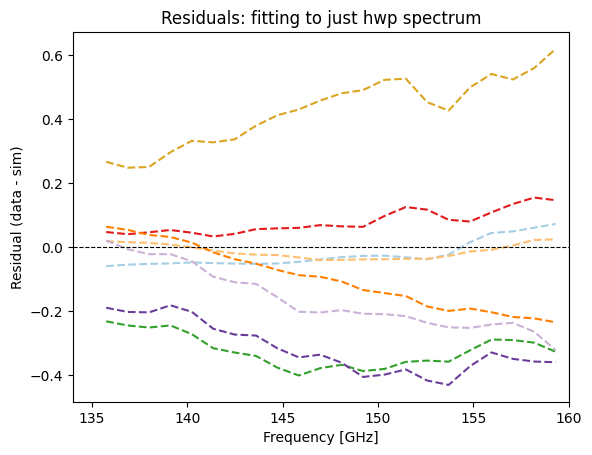

In [92]:
plt.figure()

# vna hwp residuals and fitting to only R
for i, obs_residuals in residuals_fitting_hwp_ps.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= 135) & (val['freq'] <= 160)
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls='--')

plt.axhline(0, color='k', lw=0.8, ls='--')
# plt.axvline(130, color='gray', lw=0.8)
plt.axvline(160, color='gray', lw=0.8)
plt.xlim(134, 160)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Residual (data - sim)')
plt.title(f'Residuals: fitting to just hwp spectrum')
plt.show()

# Fit 4

Attempt 1:

1. fit to everything for first guesses (use 5th order R)
2. fit to hwp spectrum
3. fit to higher order R

^ Not able to do things in this order because the fitted hwp spectrum is not physical.

Attempt 2:

1. fit to everything for first guesses (use 5th order R)
2. fit to higher order R
3. fit to hwp spectrum

## Attempt 1

In [145]:
# Fit to the HWP spectrum again
# ── fixed givens: average of the VNA-based and FTS-based band fits ──────────
x_avg = (result_v3.x + result_v3_fts.x) / 2
fitted_alphas_arr_avg = x_avg[:n_bands]
angle_stat_fit_avg    = x_avg[n_bands]
poly_fit_avg          = x_avg[n_bands + 1:]

# ── initial guess: average of VNA and FTS quadratic HWP phase-shift fits ────
# mask_vna = np.where((f_hwp_vna >= bounds[0]) & (f_hwp_vna <= bounds[1]))
# coeffs_vna_quad = np.polyfit(f_hwp_vna[mask_vna], ps_hwp_vna[mask_vna], 2)

# mask_fts = np.where((f_hwp_fts >= bounds[0]) & (f_hwp_fts <= bounds[1]))
# coeffs_fts_quad = np.polyfit(f_hwp_fts[mask_fts], ps_hwp_fts[mask_fts], 2)

p0_v3_hwp_ps_avg = list((coeffs_vna_quad + coeffs_fts) / 2)

result_v3_fit_hwp_ps_v2 = least_squares(
    error_func3_fit_hwp_ps, p0_v3_hwp_ps_avg,
    args=(x_data_list, y_data_list, gammas, fitted_alphas_arr_avg, angle_stat_fit_avg, poly_fit_avg)
)

hwp_poly_fit_v2 = result_v3_fit_hwp_ps_v2.x

In [148]:
hwp_poly_fit_func_v2 = np.poly1d(hwp_poly_fit_v2)
hwp_poly_guess_func = np.poly1d(p0_v3_hwp_ps_avg)

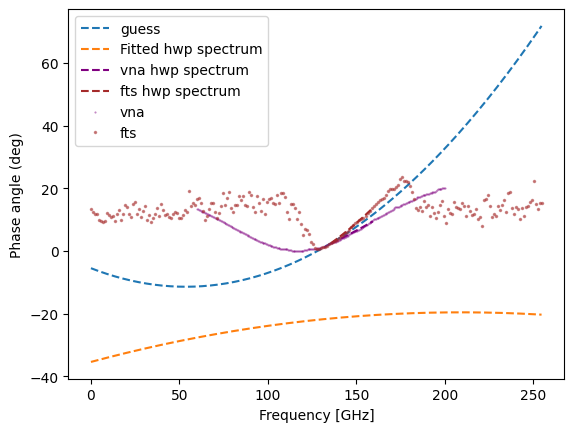

In [178]:
# See how different hwp spectra compare
plt.figure()
plt.plot(f, hwp_poly_guess_func(f), ls='--', label='guess')
plt.plot(f, hwp_poly_fit_func_v2(f), ls='--', label='Fitted hwp spectrum')

plt.plot(f[mask], vna_quad_func(f[mask]), ls='--', label='vna hwp spectrum', color='purple')
plt.plot(f[mask], ps_hwp_fts_func(f[mask]), ls='--', label='fts hwp spectrum', color='brown')


## VNA
plt.plot(mf1_ahwp['frequency (GHz)'], mf1_ahwp['phase shift (deg)'], '.', markersize=1, label='vna', color='purple', alpha=0.5)

## FTS
plt.plot(f_hwp_fts, ps_hwp_fts, '.', markersize=3,label='fts', color='brown', alpha=0.5)


plt.legend()
# plt.xlim(100, 200)
# plt.ylim(-200, 100)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Phase angle (deg)')
plt.show()

## Attempt 2

In [174]:
# fit to a higher order R

POLY_DEG_v2 = order_v2

# # ── error function ───────────────────────────────────────────────────────────
# def error_func3_fitR(params, x_data_list, y_data_list, gammas):
#     """
#     params layout: [alpha_0, ..., alpha_n, angle, poly_coeff_0, ..., poly_coeff_d]
#     """
#     n_bands = len(BAND_INDICES)
#     # alphas = params[:n_bands]
#     # angle = params[n_bands]
#     poly_coeffs = params          # length = POLY_DEG + 1

#     freqs = x_data_list[0]
#     residuals = [
#         y_data_list[i] - func3_vna(freqs, gammas[i], angle_stat_fit_vna, Cguess, fitted_alphas_arr_vna[i], poly_coeffs)
#         for i in range(n_bands)
#     ]
#     return np.concatenate(residuals)

# guess params for R(nu)
poly_p0  = list(coeffs_band_v2[:POLY_DEG_v2 + 1])   # must supply POLY_DEG+1 coeffs

p0_v3 = poly_p0

result_fitR_v2 = least_squares(error_func3_fitR, p0_v3, args=(x_data_list, y_data_list, gammas))
poly_fitR_v2 = result_fitR_v2.x

In [175]:
poly_fitR_v2_func = np.poly1d(poly_fitR_v2)


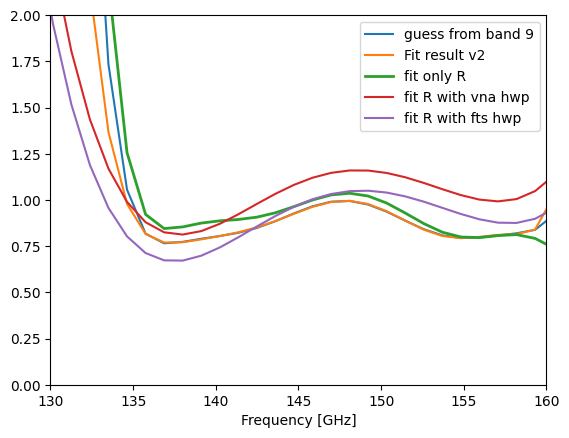

In [176]:
plt.figure()
plt.plot(f, guessfunc(f), label='guess from band 9')
plt.plot(f, poly_fitR_v2_func(f), label='Fit result v2')

plt.plot(f, fitfunc(f), label='fit only R', lw=2)
plt.plot(f, fitfuncvna(f), label='fit R with vna hwp')
plt.plot(f, fitfuncfts(f), label='fit R with fts hwp')

plt.legend()
plt.xlim(130, 160)
plt.ylim(0, 2)
plt.xlabel('Frequency [GHz]')
plt.show()

# Plot 4

## Attempt 2

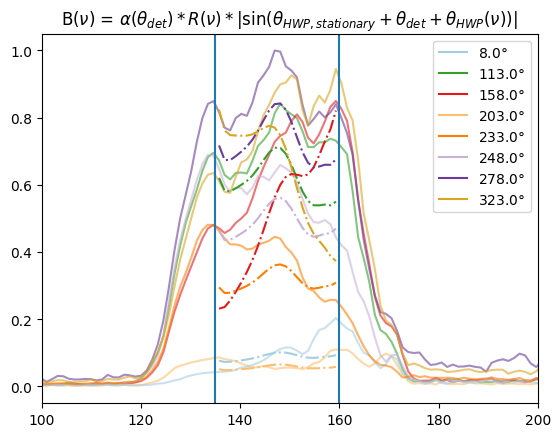

In [177]:
# ── plot ──────────────────────────────────────────────────────────────────────
plt.figure()
# fig, ax = plt.subplots(1, 2)

for i in range(n_groups):
    band = np.array(bands_groups1_bs_norm[i])
    freq = mv19_obs1['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)

for i in range(n_groups):
    band = np.array(bands_groups4_bs_norm[i])
    freq = mv19_obs4['passband_results'][0]['frequency_ghz']
    mask_ = ~np.isnan(band)
    if mask_.any():
        plt.plot(freq[mask_], band[mask_], color=colors[i], alpha=0.6)
    
# fit when using vna hwp and fitted to R with other stuff constant
for i, alpha_fit in fitted_alphas_vna.items():
    y_fit = func3_vna(f[mask], gammas_avg[i], angle_stat_fit_vna, Cguess, alpha_fit, poly_fitR_v2)
    plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='-.', alpha=1)

    # y_fit = func3_vna(f[mask], gammas_avg[i], 265, Cguess, alpha_fit, poly_fit_fitR)
    # plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls='-.')

# # fit when using fts hwp
# for i, alpha_fit in fitted_alphas_fts.items():
#     y_fit = func3_fts(f[mask], gammas_avg[i], angle_stat_fit_fts, Cguess, alpha_fit, poly_fit_fts)
#     plt.plot(f[mask], np.abs(y_fit), color=colors[i], ls=':')

# Label the pol angles
for i, (group_obs4, group_obs1, color) in enumerate(zip(groups_obs4, groups_obs1, colors)):
    if len(group_obs4) > 0:
        gamma_avg = np.degrees(np.mean(gamma4[group_obs4]))
        gammas_avg[i] = gamma_avg
    else:
        gamma_avg = np.degrees(np.mean(gamma1[group_obs1]))
        gammas_avg[i] = gamma_avg
    if math.isnan(gamma_avg):
        continue
    plt.plot([], [], color=color, label=rf'{np.round(gamma_avg)}$\degree$')

plt.legend()
# 
plt.xlim(100, 200)

# plt.axvspan(130, 160, alpha=0.5)
plt.axvline(135)
plt.axvline(160)
# ax[0].axhline(0.06, ls='--')
# ax[1].axhline(0.06, ls='--')
equationString = r'B($\nu$) = $\alpha (\theta_{det}) * R(\nu) * |$sin($\theta_{HWP, stationary} + \theta_{det} + \theta_{HWP}(\nu)$)|'

plt.title(equationString)
plt.show()

In [169]:
residuals_vna_fitR_v2 = {}
# freq = mv19_obs1['passband_results'][0]['frequency_ghz']

for i, alpha_fit in fitted_alphas_vna.items():
    y_fit = np.abs(func3_vna(f[mask], gammas_avg[i], angle_stat_fit_vna, Cguess, alpha_fit, poly_fitR_v2))
    y_fit_interp = np.interp(freq, f[mask], y_fit)

    residuals_vna_fitR_v2[i] = {}
    for obs, band_norm in [('obs1', bands_groups1_bs_norm[i]), ('obs4', bands_groups4_bs_norm[i])]:
        band = np.array(band_norm)
        if np.ndim(band) == 0:
            residuals_vna_fitR[i][obs] = None
            continue
        mask_ = ~np.isnan(band)
        residuals_vna_fitR_v2[i][obs] = {
            'freq': freq[mask_],
            'resid': band[mask_] - y_fit_interp[mask_],
        }

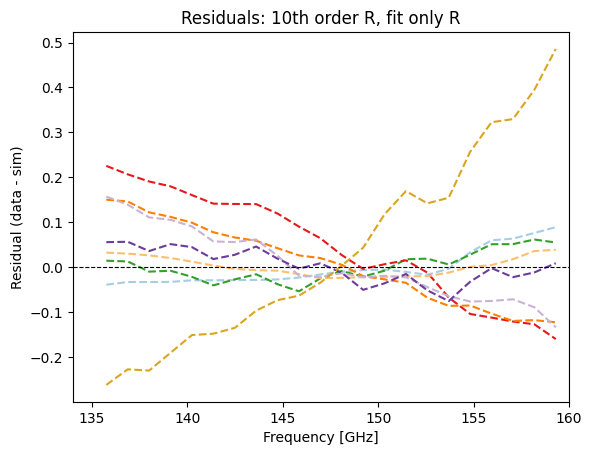

In [171]:
plt.figure()

# vna hwp residuals and fitting to only R
for i, obs_residuals in residuals_vna_fitR.items():
    for obs, val in obs_residuals.items():
        if val is not None:
            freq_mask = (val['freq'] >= 135) & (val['freq'] <= 160)
            plt.plot(val['freq'][freq_mask], val['resid'][freq_mask], color=colors[i], ls='--')

plt.axhline(0, color='k', lw=0.8, ls='--')
# plt.axvline(130, color='gray', lw=0.8)
plt.axvline(160, color='gray', lw=0.8)
plt.xlim(134, 160)
plt.xlabel('Frequency [GHz]')
plt.ylabel('Residual (data - sim)')
plt.title(f'Residuals: {order_v2}th order R, fit only R')
plt.show()

# Scratch

In [ ]:
# to see if the fitting is actually doing anything
print(result_v3.message)
print(result_v3.cost)
print(result_v3.optimality)  # should be small if converged

# Check 1: are your p0 and result the same length?
print('p0 length:', len(p0_v3))
print('expected:', len(BAND_IbNDICES) + 1 + (POLY_DEG + 1))

# Check 2: did the optimizer even run?
print(result_v3.message)
print('nfev:', result_v3.nfev)   # number of function evaluations; 1 means it never moved
print('cost:', result_v3.cost)

# Check 3: verify the error function returns sensible values at p0
test_res = error_func3(p0_v3, x_data_list, y_data_list, gammas)
print('residual at p0 - mean:', np.mean(test_res), 'std:', np.std(test_res))